# Deep Learning — Tenseurs & Gradients (Notebook **exercices guidés**)

Ce notebook est conçu pour un cours/TD : il alterne **explications courtes** et **cellules à compléter**.

## Règles:
- Les cellules marquées **À COMPLÉTER** contiennent des `TODO`.
- Les cellules **Tests** vérifient automatiquement si votre réponse est cohérente.
- Les cellules **Bonus** sont optionnelles.
- Les cellules **Correction** sont là pour l’enseignant (vous pouvez les ignorer / les masquer / les supprimer).

---


In [1]:
## Imports
# Si besoin : !pip install torch matplotlib
import math
import torch
import matplotlib.pyplot as plt

torch.set_printoptions(precision=4, sci_mode=False)
print('Torch version:', torch.__version__)


Torch version: 2.10.0+cpu


## Partie 1 — Tenseurs (shapes, indexation, broadcast)

### 1.1 Créer des tenseurs
Un tenseur est un tableau multi-dimensionnel. Sa **shape** (forme) décrit ses dimensions.

Exemples :
- scalaire : shape `[]`
- vecteur : shape `[n]`
- matrice : shape `[n, m]`

Dans les cellules suivantes, vous allez créer des tenseurs et vérifier leurs shapes.


###  À COMPLÉTER — Créer des tenseurs de shapes données

In [6]:
# TODO 1) Créez un scalaire 'a' égal à 3.0
# TODO 2) Créez un vecteur 'v' contenant [1.0, 2.0, 3.0]
# TODO 3) Créez une matrice 'M' de shape (3,2) : [[1,2],[3,4],[5,6]] (en float)

a =torch.tensor(3.0)
v = torch.tensor([1.0, 2.0, 3.0])
M = torch.tensor([[1.0,2.0], [3.0,4.0], [5.0,6.0] ])

print('a =', a, 'shape =', None if a is None else a.shape)
print('v =', v, 'shape =', None if v is None else v.shape)
print('M =\n', M, '\nshape =', None if M is None else M.shape)


a = tensor(3.) shape = torch.Size([])
v = tensor([1., 2., 3.]) shape = torch.Size([3])
M =
 tensor([[1., 2.],
        [3., 4.],
        [5., 6.]]) 
shape = torch.Size([3, 2])


### Tests — shapes

In [7]:
assert isinstance(a, torch.Tensor), 'a doit être un torch.Tensor'
assert a.shape == torch.Size([]), f"shape(a) attendue [], obtenu {a.shape}"
assert torch.isclose(a, torch.tensor(3.0)), 'a doit valoir 3.0'

assert v.shape == torch.Size([3]), f"shape(v) attendue [3], obtenu {v.shape}"
assert torch.allclose(v, torch.tensor([1.0,2.0,3.0])), 'v incorrect'

assert M.shape == torch.Size([3,2]), f"shape(M) attendue [3,2], obtenu {M.shape}"
assert torch.allclose(M, torch.tensor([[1.0,2.0],[3.0,4.0],[5.0,6.0]])), 'M incorrect'
print('✅ Tests OK')


✅ Tests OK


### 1.2 Indexation et slicing
- `M[i, j]` : élément ligne i, colonne j
- `M[:, 0]` : première colonne
- `M[1:]` : de la ligne 1 jusqu’à la fin

Vous allez extraire des sous-tenseurs et vérifier.


###  À COMPLÉTER — extraire des éléments

In [8]:
# On suppose que M est défini (Partie 1.1)

# TODO 1) stockez dans x l'élément M[0,1]
# TODO 2) stockez dans col0 la première colonne M[:,0]
# TODO 3) stockez dans sub les lignes à partir de l'index 1 : M[1:]

x = M[0,1]
col0 = M[:,0]
sub = M[1:]

print('x =', x)
print('col0 =', col0)
print('sub =\n', sub)


x = tensor(2.)
col0 = tensor([1., 3., 5.])
sub =
 tensor([[3., 4.],
        [5., 6.]])


###  Tests — indexation

In [9]:
assert x.shape == torch.Size([]), 'x doit être un scalaire'
assert torch.isclose(x, torch.tensor(2.0)), f"x attendu 2.0, obtenu {x}"

assert col0.shape == torch.Size([3]), f"col0 shape attendue [3], obtenu {col0.shape}"
assert torch.allclose(col0, torch.tensor([1.0,3.0,5.0])), 'col0 incorrect'

assert sub.shape == torch.Size([2,2]), f"sub shape attendue [2,2], obtenu {sub.shape}"
assert torch.allclose(sub, torch.tensor([[3.0,4.0],[5.0,6.0]])), 'sub incorrect'
print(' Tests OK')


 Tests OK


### 1.3 Broadcast (super important en deep learning)

Souvent, on a une matrice de données `X` de shape `(N, D)` et un biais `b` de shape `(D,)`.
L’opération `X + b` **ajoute b à chaque ligne** de X (broadcast).

Vous allez reproduire ce mécanisme.


###  À COMPLÉTER — broadcast biais

In [10]:
# TODO 1) créez X de shape (2,3) : [[1,2,3],[4,5,6]]
# TODO 2) créez b de shape (3,) : [0.1, 0.2, 0.3]
# TODO 3) calculez Y = X + b

X = torch.tensor([[1.0,2.0,3.0],[4.0,5.0,6.0]])
b = torch.tensor([0.1, 0.2, 0.3])
Y = X+b

print('X shape:', None if X is None else X.shape)
print('b shape:', None if b is None else b.shape)
print('Y =\n', Y)


X shape: torch.Size([2, 3])
b shape: torch.Size([3])
Y =
 tensor([[1.1000, 2.2000, 3.3000],
        [4.1000, 5.2000, 6.3000]])


###  Tests — broadcast

In [11]:
assert X.shape == torch.Size([2,3])
assert b.shape == torch.Size([3])
expected = torch.tensor([[1.1,2.2,3.3],[4.1,5.2,6.3]])
assert torch.allclose(Y, expected), f"Y incorrect\nattendu=\n{expected}\nobtenu=\n{Y}"
print('✅ Tests OK')


✅ Tests OK


## Partie 2 — Gradient : intuition & descente de gradient (1D)

On veut minimiser une **loss** `L(w)`.
Le gradient (en 1D : la dérivée) indique comment `L` varie quand on change `w`.

Exemple :
\[ L(w) = (w-3)^2 \]
Dérivée :
\[ \frac{dL}{dw} = 2(w-3) \]

Vous allez implémenter la descente de gradient **à la main**.


### À COMPLÉTER — gradient descent 1D

In [14]:
def L(w):
    # loss 1D
    return (w - 3.0)**2

def dL_dw(w):
    # TODO: écrire la dérivée 2*(w-3)
    return 2*(w-3)

w = 8.0
eta = 0.1
history = []

for step in range(100): # Increased steps to allow for better convergence
    # TODO: calculez le gradient g = dL_dw(w)
    g = dL_dw(w)
    # TODO: mettez à jour w <- w - eta*g
    w = w - eta*g
    history.append((step, w, L(w)))

history[:5], history[-1]

([(0, 7.0, 16.0),
  (1, 6.2, 10.240000000000002),
  (2, 5.5600000000000005, 6.553600000000003),
  (3, 5.048, 4.194304),
  (4, 4.6384, 2.6843545599999996)],
 (99, 3.000000001018518, 1.0373792396055266e-18))

### Tests — convergence vers 3

In [15]:
last_w = history[-1][1]
assert abs(last_w - 3.0) < 1e-2, f"w doit converger vers 3, obtenu {last_w}"
print(' Convergence OK, w_final =', last_w)


 Convergence OK, w_final = 3.000000001018518


###  Visualisation

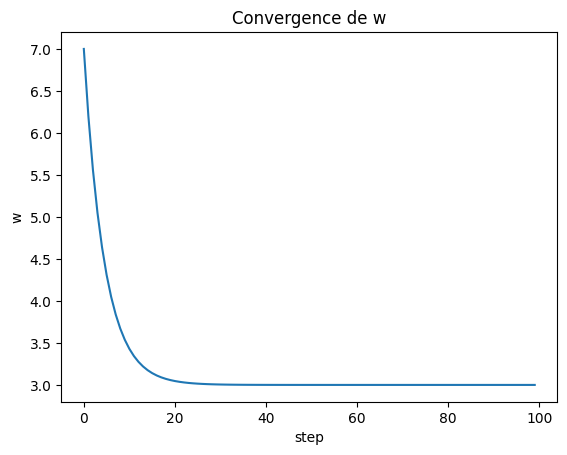

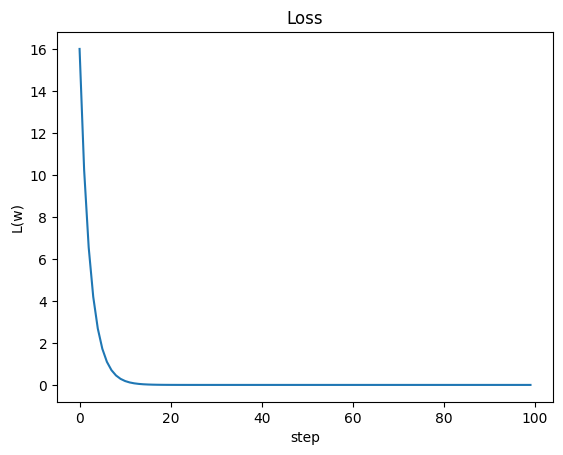

In [16]:
steps = [h[0] for h in history]
ws_hist = [h[1] for h in history]
Ls_hist = [h[2] for h in history]

plt.figure()
plt.plot(steps, ws_hist)
plt.xlabel('step')
plt.ylabel('w')
plt.title('Convergence de w')
plt.show()

plt.figure()
plt.plot(steps, Ls_hist)
plt.xlabel('step')
plt.ylabel('L(w)')
plt.title('Loss')
plt.show()


## Partie 3 — Autograd (PyTorch) : gradients automatiquement

PyTorch peut construire un graphe de calcul et calculer automatiquement les gradients.

Rappel :
- Déclarer `requires_grad=True`
- Calculer une loss (scalaire)
- Appeler `loss.backward()`
- Lire le gradient dans `x.grad`


### À COMPLÉTER — calcul de gradient avec autograd

In [17]:
# On veut calculer dy/dx pour y = (2x)^2

x = torch.tensor(2.0, requires_grad=True)

# TODO 1) définissez u = 2*x
u = 2*x
# TODO 2) définissez y = u**2
y = u**2

# TODO 3) lancez y.backward()
y.backward()

# Vérification
print('x =', x.item())
print('y =', None if y is None else y.item())
print('dy/dx =', None if x.grad is None else x.grad.item())


x = 2.0
y = 16.0
dy/dx = 16.0


###  Tests — dy/dx = 8x = 16 quand x=2

In [18]:
assert x.grad is not None, 'Vous devez appeler backward()'
assert abs(x.grad.item() - 16.0) < 1e-6, f"dy/dx attendu 16.0, obtenu {x.grad.item()}"
print('✅ Tests OK')


✅ Tests OK


## Partie 4 — Régression linéaire (vrai mini entraînement)

On veut apprendre un modèle :  
\[ \hat{y} = w x + b \]

avec la MSE :
\[ \text{MSE} = \frac{1}{N}\sum_i (\hat{y}_i - y_i)^2 \]

Vous allez compléter la boucle d'entraînement.


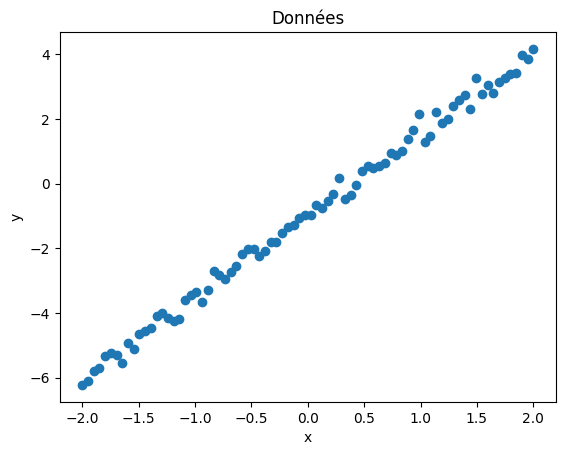

In [19]:
torch.manual_seed(0)

# Données : y = 2.5 x - 1.0 + bruit
N = 80
x_data = torch.linspace(-2, 2, N).unsqueeze(1)  # (N,1)
y_true = 2.5*x_data - 1.0
y_data = y_true + 0.2*torch.randn_like(y_true)

plt.figure()
plt.scatter(x_data.squeeze().numpy(), y_data.squeeze().numpy())
plt.xlabel('x')
plt.ylabel('y')
plt.title('Données')
plt.show()


### À COMPLÉTER — boucle d'entraînement (autograd + update manuel)

In [28]:

# Initialisation paramètres
w = torch.randn(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)
lr = 0.5

losses = []
for epoch in range(200):
    # TODO 1) prédiction y_hat = w*x_data + b
    y_hat = w*x_data + b
    # TODO 2) loss = MSE
    loss = torch.nn.functional.mse_loss(y_hat, y_data)

    # TODO 3) backward
    loss.backward()
    # TODO 4) update des paramètres (dans torch.no_grad())
    #         w -= lr*w.grad ; b -= lr*b.grad
    with torch.no_grad():
        w -= lr*w.grad
        b -= lr*b.grad
    # TODO 5) remettre les gradients à zéro
    w.grad.zero_()
    b.grad.zero_()
    losses.append(loss.item())

print('w appris:', w.item())
print('b appris:', b.item())

w appris: 2.5177013874053955
b appris: -0.9820257425308228


###  Tests — paramètres proches de (2.5, -1.0)

In [25]:
assert abs(w.item() - 2.5) < 0.2, f"w devrait être proche de 2.5, obtenu {w.item()}"
assert abs(b.item() + 1.0) < 0.2, f"b devrait être proche de -1.0, obtenu {b.item()}"
print('✅ Tests OK')


✅ Tests OK


### Visualisation

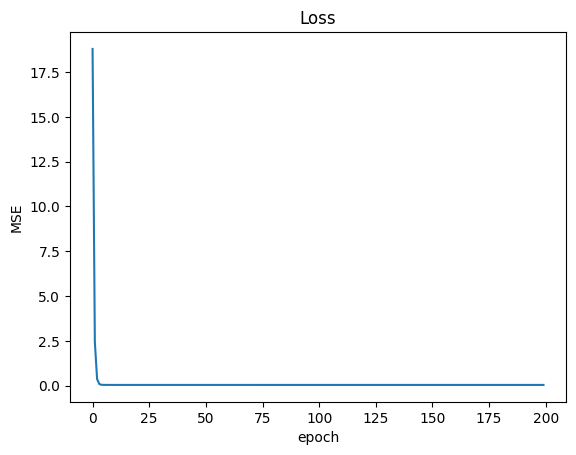

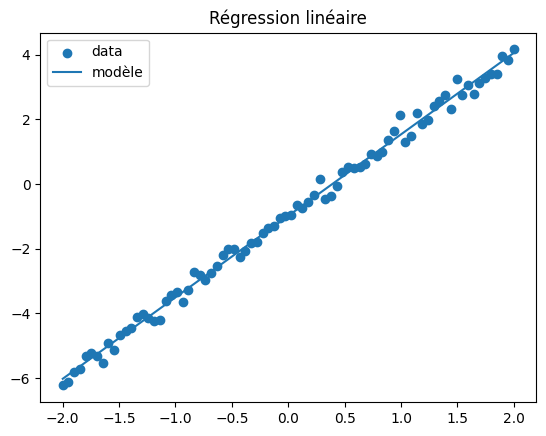

In [29]:
plt.figure()
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.title('Loss')
plt.show()

with torch.no_grad():
    y_hat = w*x_data + b

plt.figure()
plt.scatter(x_data.squeeze().numpy(), y_data.squeeze().numpy(), label='data')
plt.plot(x_data.squeeze().numpy(), y_hat.squeeze().numpy(), label='modèle')
plt.legend()
plt.title('Régression linéaire')
plt.show()


In [30]:

## 1) Essayez différents learning rates (0.5, 0.1, 0.01) sur la régression linéaire : convergence / divergence.


## Partie 5 — Mini MLP (rétropropagation "en vrai")

On entraîne un petit réseau pour approximer une fonction non-linéaire :  
\[ y = \sin(3x) + \epsilon \]

Architecture :
- Linear(1 → 32) → ReLU → Linear(32 → 1)

Vous allez compléter l'entraînement standard : forward → loss → zero_grad → backward → step.


In [31]:
torch.manual_seed(0)
N = 200
x = torch.linspace(-2, 2, N).unsqueeze(1)
y = torch.sin(3*x) + 0.1*torch.randn_like(x)

model = torch.nn.Sequential(
    torch.nn.Linear(1, 32),
    torch.nn.ReLU(),
    torch.nn.Linear(32, 1)
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.02)
loss_fn = torch.nn.MSELoss()


### À COMPLÉTER — boucle d'entraînement MLP

In [32]:
losses = []
for epoch in range(400):
    # TODO 1) forward : y_hat = model(x)
    y_hat = model(x)
    # TODO 2) loss
    loss = loss_fn(y_hat, y)

    # TODO 3) optimizer.zero_grad()
    optimizer.zero_grad()
    # TODO 4) backward
    loss.backward()
    # TODO 5) optimizer.step()
    optimizer.step()
    losses.append(loss.item())

print('loss finale:', losses[-1])


loss finale: 0.10625945776700974


### Tests — la loss doit baisser

In [33]:
assert losses[0] > losses[-1], 'La loss devrait diminuer entre le début et la fin.'
assert losses[-1] < 0.05, f"On attend une loss finale raisonnable (<0.05), obtenu {losses[-1]}"
print('✅ Tests OK')


AssertionError: On attend une loss finale raisonnable (<0.05), obtenu 0.10625945776700974

In [ ]:
## 2) Remplacez ReLU par Tanh dans le MLP et comparez la loss finale.
## 3) Ajoutez une seconde couche cachée (Linear → ReLU → Linear → ReLU → Linear) et observez l’effet.


### Visualisation MLP

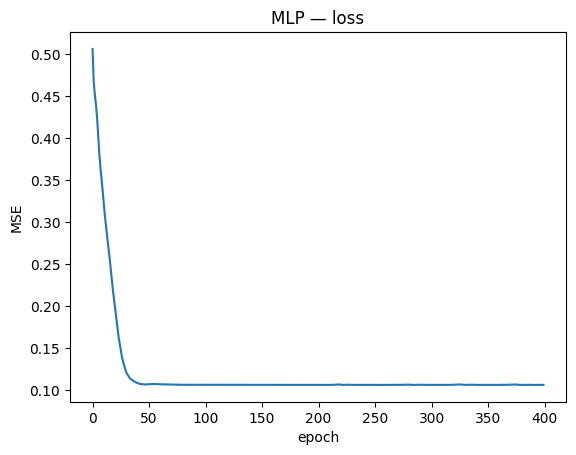

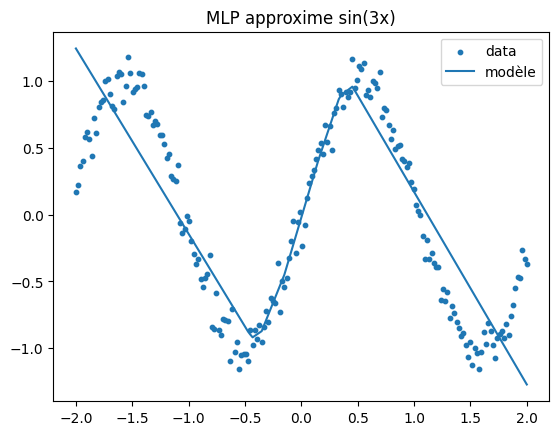

In [34]:
plt.figure()
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.title('MLP — loss')
plt.show()

with torch.no_grad():
    y_hat = model(x)

plt.figure()
plt.scatter(x.squeeze().numpy(), y.squeeze().numpy(), s=10, label='data')
plt.plot(x.squeeze().numpy(), y_hat.squeeze().numpy(), label='modèle')
plt.legend()
plt.title('MLP approxime sin(3x)')
plt.show()


## Partie 6 — Inspecter les gradients (.grad)

Après `backward()`, chaque paramètre `p` a un gradient `p.grad`.
Vous allez faire un **seul** pas de calcul de gradient et afficher des normes.


### À COMPLÉTER — afficher la norme des gradients

In [35]:
model = torch.nn.Sequential(
    torch.nn.Linear(1, 4),
    torch.nn.Tanh(),
    torch.nn.Linear(4, 1)
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

# TODO 1) forward
y_hat = model(x)
# TODO 2) loss
loss = loss_fn(y_hat,y)

# TODO 3) optimizer.zero_grad()
optimizer.zero_grad()
# TODO 4) loss.backward()
loss.backward()

for name, p in model.named_parameters():
    # TODO 5) affichez le shape du paramètre et la norme du gradient p.grad.norm()
    print(name, p.shape, p.grad.norm())
    pass


0.weight torch.Size([4, 1]) tensor(0.1081)
0.bias torch.Size([4]) tensor(0.2782)
2.weight torch.Size([1, 4]) tensor(0.2353)
2.bias torch.Size([1]) tensor(0.6888)


###  Tests — gradients non nuls

In [36]:
grads = []
for _, p in model.named_parameters():
    assert p.grad is not None, 'Appelez backward() avant de lire p.grad'
    grads.append(p.grad.abs().sum().item())
assert sum(grads) > 0, 'Les gradients semblent tous nuls : vérifiez votre forward/loss/backward.'
print(' Tests OK')


 Tests OK
